# Tarea 2.2 - Simulación de escenarios futuros

Importar los precios de Amazon desde Yahoo finance de los últimos 10 años y simular cien mil escenarios de los próximos 30 días para predecir la probabilidad de que el precio actual supere el 8%.


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
inicio = '2014-11-2'
fin = '2024-11-2'
data = yf.download('AMZN', start=inicio, end=fin)['Adj Close']

[*********************100%***********************]  1 of 1 completed


In [38]:
prices = data.pct_change().dropna()

nDias = 30
nSimulations = 100000
dates = pd.date_range('2024-11-2',periods=30)

pricesSimulated = pd.DataFrame(np.random.normal(prices.mean(),prices.std(),size=(nDias,nSimulations)),dates)

Probabilidad de que el precio de la acción de Amazon suba un 8% en 30 días


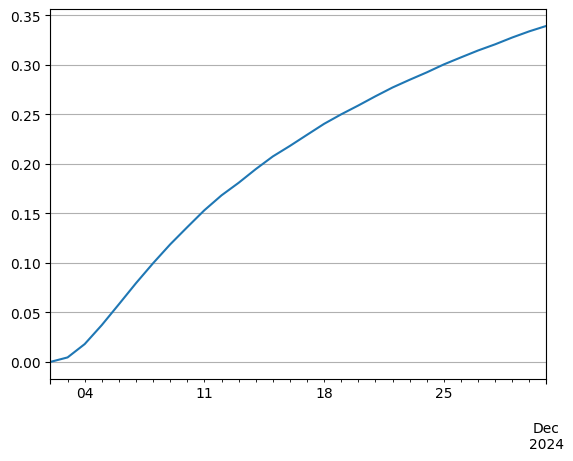

In [40]:
(data.iloc[-1,0]*(pricesSimulated+1).cumprod(axis=0) > data.iloc[-1,0]*1.08).mean(axis=1).plot(grid=True)
print('Probabilidad de que el precio de la acción de Amazon suba un 8% en 30 días')
plt.show()